Device: cuda
Model: sentence-transformers/all-mpnet-base-v2

Loading data...
Number of classes: 8
Total samples: 322

Class distribution:
  Class 0: 47 samples (14.60%)
  Class 1: 27 samples (8.39%)
  Class 2: 45 samples (13.98%)
  Class 3: 8 samples (2.48%)
  Class 4: 54 samples (16.77%)
  Class 5: 65 samples (20.19%)
  Class 6: 37 samples (11.49%)
  Class 7: 39 samples (12.11%)

Class weights for loss function:
  Class 0: 0.8564
  Class 1: 1.4907
  Class 2: 0.8944
  Class 3: 5.0312
  Class 4: 0.7454
  Class 5: 0.6192
  Class 6: 1.0878
  Class 7: 1.0321

Sample text (first 200 chars):
4 male 33.0 Chewing pain in upper right back tooth for several days  I have been unable to chew food for a long time after biting hard objects with my upper right back teeth. It has worsened recently ...

Train samples: 225
Val samples: 97

Loading medical domain encoder: sentence-transformers/all-mpnet-base-v2
Embedding dimension: 768

Encoding training data...


Batches: 100%|██████████| 8/8 [00:00<00:00,  8.94it/s]


Encoding validation data...


Batches: 100%|██████████| 4/4 [00:00<00:00, 10.59it/s]


Training embeddings shape: torch.Size([225, 768])
Validation embeddings shape: torch.Size([97, 768])

Saving embeddings to 'embeddings_for_multimodal/' for multimodal fusion...
Saved train embeddings: torch.Size([225, 768])
Saved val embeddings: torch.Size([97, 768])
Embedding dimension: 768
Metadata saved for multimodal fusion

Model created:
Total parameters: 565,672
Trainable parameters: 565,672

Using weighted CrossEntropyLoss to handle class imbalance

STARTING TRAINING WITH MEDICAL DOMAIN MODEL

Epoch   1/100 | Train Acc: 0.1778 | Val Acc: 0.3505 | Train Loss: 2.1929 | Val Loss: 2.0309
   New best validation accuracy: 0.3505
Epoch   2/100 | Train Acc: 0.3333 | Val Acc: 0.5155 | Train Loss: 2.0848 | Val Loss: 1.8741
   New best validation accuracy: 0.5155
Epoch   3/100 | Train Acc: 0.4444 | Val Acc: 0.5155 | Train Loss: 1.9583 | Val Loss: 1.8235
Epoch   4/100 | Train Acc: 0.5156 | Val Acc: 0.5464 | Train Loss: 1.8588 | Val Loss: 1.7315
   New best validation accuracy: 0.5464
Epoch

C:\Users\T2510590\AppData\Local\Temp\ipykernel_8304\430874469.py:297: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_medical_model.pth'

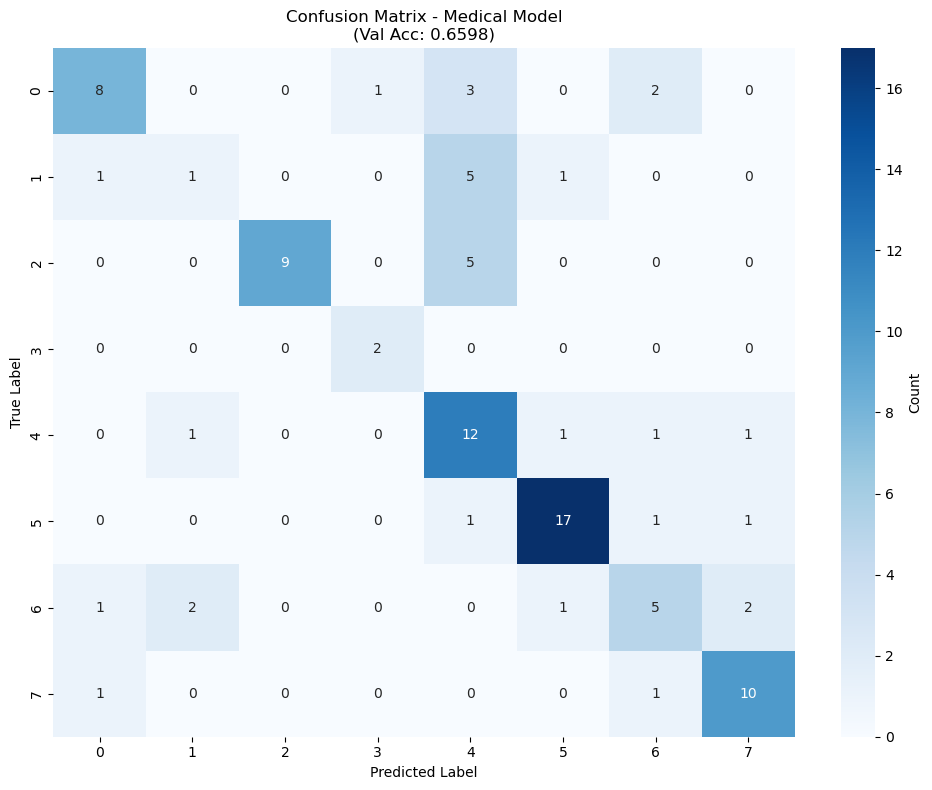

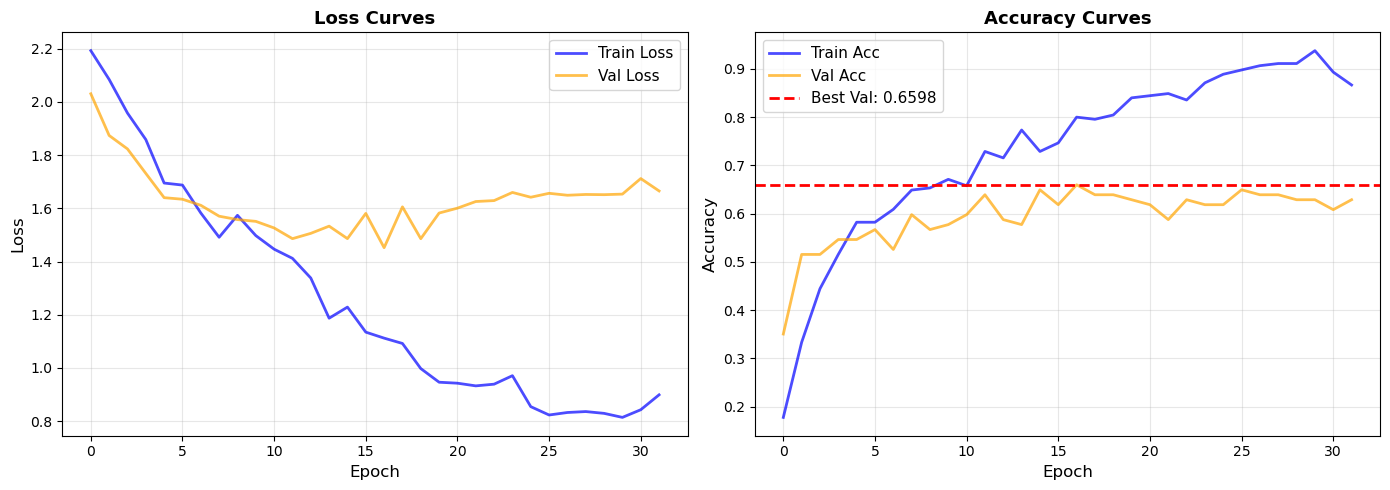


✓ Training complete!
✓ Best model saved as 'best_medical_model.pth'
✓ Plots saved as 'confusion_matrix_medical.png' and 'training_curves_medical.png'

EMBEDDINGS SAVED FOR MULTIMODAL FUSION
Location: embeddings_for_multimodal/
Files:
  - train_text_embeddings.pt  (torch.Size([225, 768]))
  - val_text_embeddings.pt    (torch.Size([97, 768]))
  - train_labels.pt, val_labels.pt
  - train_texts.npy, val_texts.npy (original texts)
  - metadata.pt (embedding info)

To load for multimodal fusion:
  train_emb = torch.load('embeddings_for_multimodal/train_text_embeddings.pt')
  train_labels = torch.load('embeddings_for_multimodal/train_labels.pt')
  metadata = torch.load('embeddings_for_multimodal/metadata.pt')


In [ ]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


CSV_PATH = "mmdental_multiclass_new.csv"
EMB_SAVE_DIR = "embeddings_for_multimodal"  # embeddings for multimodal use
BATCH_SIZE = 16
EPOCHS = 100
LR = 5e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


os.makedirs(EMB_SAVE_DIR, exist_ok=True)

#
MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"


print(f"Device: {DEVICE}")
print(f"Model: {MODEL_NAME}")

#  LOAD DATA
print("\nLoading data...")
df = pd.read_csv(CSV_PATH)
df = df.drop(columns=["target_disease"])

labels = df["label"].values
num_classes = len(np.unique(labels))
print(f"Number of classes: {num_classes}")
print(f"Total samples: {len(labels)}")

class_counts = np.bincount(labels)
print(f"\nClass distribution:")
for i, count in enumerate(class_counts):
    percentage = (count / len(labels)) * 100
    print(f"  Class {i}: {count} samples ({percentage:.2f}%)")

# class weights for imbalanced data
class_weights = len(labels) / (num_classes * class_counts)
class_weights = torch.FloatTensor(class_weights).to(DEVICE)
print(f"\nClass weights for loss function:")
for i, weight in enumerate(class_weights):
    print(f"  Class {i}: {weight:.4f}")

text_cols = [c for c in df.columns if c != "label"]
df["text"] = df[text_cols].astype(str).agg(" ".join, axis=1)
texts = df["text"].tolist()

print(f"\nSample text (first 200 chars):\n{texts[0][:200]}...")

X_train, X_val, y_train, y_val = train_test_split(
    texts, labels, test_size=0.3, stratify=labels, random_state=42
)

print(f"\nTrain samples: {len(X_train)}")
print(f"Val samples: {len(X_val)}")

print(f"\nLoading medical domain encoder: {MODEL_NAME}")
text_encoder = SentenceTransformer(MODEL_NAME, device=DEVICE)
EMB_DIM = text_encoder.get_sentence_embedding_dimension()
print(f"Embedding dimension: {EMB_DIM}")

print("\nEncoding training data...")
X_train_emb = text_encoder.encode(
    X_train,
    convert_to_tensor=True,
    device=DEVICE,
    show_progress_bar=True,
    batch_size=32
)

print("Encoding validation data...")
X_val_emb = text_encoder.encode(
    X_val,
    convert_to_tensor=True,
    device=DEVICE,
    show_progress_bar=True,
    batch_size=32
)

# Convert labels to tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

print(f"Training embeddings shape: {X_train_emb.shape}")
print(f"Validation embeddings shape: {X_val_emb.shape}")

#SAVE EMBEDDINGS FOR MULTIMODAL USE
print(f"\nSaving embeddings to '{EMB_SAVE_DIR}/' for multimodal fusion...")

# Save training embeddings and labels
torch.save(X_train_emb.cpu(), f"{EMB_SAVE_DIR}/train_text_embeddings.pt")
torch.save(y_train_tensor, f"{EMB_SAVE_DIR}/train_labels.pt")
np.save(f"{EMB_SAVE_DIR}/train_texts.npy", np.array(X_train))

# Save validation embeddings and labels
torch.save(X_val_emb.cpu(), f"{EMB_SAVE_DIR}/val_text_embeddings.pt")
torch.save(y_val_tensor, f"{EMB_SAVE_DIR}/val_labels.pt")
np.save(f"{EMB_SAVE_DIR}/val_texts.npy", np.array(X_val))

# Save metadata for multimodal integration
metadata = {
    'embedding_dim': EMB_DIM,
    'num_classes': num_classes,
    'model_name': MODEL_NAME,
    'num_train_samples': len(X_train),
    'num_val_samples': len(X_val),
    'text_columns': text_cols,
}
torch.save(metadata, f"{EMB_SAVE_DIR}/metadata.pt")

print(f"Saved train embeddings: {X_train_emb.shape}")
print(f"Saved val embeddings: {X_val_emb.shape}")
print(f"Embedding dimension: {EMB_DIM}")
print(f"Metadata saved for multimodal fusion")

# ---------------- DATASET FOR PRE-COMPUTED EMBEDDINGS ----------------
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = embeddings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

train_ds = EmbeddingDataset(X_train_emb, y_train_tensor)
val_ds = EmbeddingDataset(X_val_emb, y_val_tensor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

class RobustClassifier(nn.Module):
    def __init__(self, emb_dim, num_classes, dropout=0.25):
        super().__init__()

        self.net = nn.Sequential(
            # First block
            nn.LayerNorm(emb_dim),
            nn.Linear(emb_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),

            # Second block
            nn.LayerNorm(512),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout),

            # Third block
            nn.LayerNorm(256),
            nn.Linear(256, 128),
            nn.GELU(),

            nn.LayerNorm(128),
            nn.Linear(128, 32),
            nn.GELU(),
            # nn.Dropout(dropout * 0.7),

            # Output layer
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = RobustClassifier(EMB_DIM, num_classes, dropout=0.5).to(DEVICE)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel created:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ---------------- TRAINING SETUP ----------------
# Weighted loss function to handle class imbalance
criterion = nn.CrossEntropyLoss(
    weight=class_weights,  # Apply class weights
    label_smoothing=0.1
)
print(f"\nUsing weighted CrossEntropyLoss to handle class imbalance")

# AdamW with weight decay for regularization
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=0.05
)

# Cosine annealing scheduler for better convergence
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

# Early stopping parameters
best_val_acc = 0
patience = 15
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

# ---------------- TRAINING LOOP ----------------
print("\n" + "="*60)
print("STARTING TRAINING WITH MEDICAL DOMAIN MODEL")
print("="*60 + "\n")

for epoch in range(EPOCHS):
    # TRAINING
    model.train()
    total_loss, correct, total = 0, 0, 0

    for emb, y in train_loader:
        emb, y = emb.to(DEVICE), y.to(DEVICE)

        logits = model(emb)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    scheduler.step()

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # VALIDATION
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for emb, y in val_loader:
            emb, y = emb.to(DEVICE), y.to(DEVICE)

            logits = model(emb)
            loss = criterion(logits, y)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    val_loss = total_loss / len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Print progress
    if (epoch + 1) % 5 == 0 or epoch < 5:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Early stopping and model saving
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_medical_model.pth')
        print(f"   New best validation accuracy: {val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⚠ Early stopping triggered at epoch {epoch+1}")
            print(f"Best validation accuracy: {best_val_acc:.4f}")
            break

# Load best model for final evaluation
print(f"\nLoading best model (Val Acc: {best_val_acc:.4f})...")
model.load_state_dict(torch.load('best_medical_model.pth'))

# ---------------- FINAL EVALUATION ----------------
print("\n" + "="*60)
print("FINAL EVALUATION ON VALIDATION SET")
print("="*60 + "\n")

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for emb, y in val_loader:
        emb, y = emb.to(DEVICE), y.to(DEVICE)
        logits = model(emb)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

final_acc = (np.array(all_preds) == np.array(all_labels)).mean()

print(f"BEST VALIDATION ACCURACY: {best_val_acc:.4f}")
print(f"Final overfitting gap: {train_accs[-1] - val_accs[-1]:.4f}")
print(f"\n{'='*60}\n")

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, zero_division=0))

# Per-class accuracy analysis
print("\nPer-Class Performance:")
for i in range(num_classes):
    class_mask = np.array(all_labels) == i
    if class_mask.sum() > 0:
        class_acc = (np.array(all_preds)[class_mask] == i).mean()
        print(f"  Class {i}: {class_acc:.4f} ({class_mask.sum()} samples)")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar_kws={'label': 'Count'})
plt.title(f"Confusion Matrix - Medical Model\n(Val Acc: {best_val_acc:.4f})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig('confusion_matrix_medical.png', dpi=300, bbox_inches='tight')
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label="Train Loss", alpha=0.7, linewidth=2, color='blue')
ax1.plot(val_losses, label="Val Loss", alpha=0.7, linewidth=2, color='orange')
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.legend(fontsize=11)
ax1.set_title("Loss Curves", fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)

ax2.plot(train_accs, label="Train Acc", alpha=0.7, linewidth=2, color='blue')
ax2.plot(val_accs, label="Val Acc", alpha=0.7, linewidth=2, color='orange')
ax2.axhline(y=best_val_acc, color='red', linestyle='--',
            label=f'Best Val: {best_val_acc:.4f}', linewidth=2)
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.legend(fontsize=11)
ax2.set_title("Accuracy Curves", fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_medical.png', dpi=300, bbox_inches='tight')
plt.show()

Device: cuda
Model: sentence-transformers/all-mpnet-base-v2

Loading data...
Number of classes: 8
Total samples: 419

Class distribution:
  Class 0: 50 samples (11.93%)
  Class 1: 50 samples (11.93%)
  Class 2: 50 samples (11.93%)
  Class 3: 50 samples (11.93%)
  Class 4: 54 samples (12.89%)
  Class 5: 65 samples (15.51%)
  Class 6: 50 samples (11.93%)
  Class 7: 50 samples (11.93%)

Class weights for loss function:
  Class 0: 1.0475
  Class 1: 1.0475
  Class 2: 1.0475
  Class 3: 1.0475
  Class 4: 0.9699
  Class 5: 0.8058
  Class 6: 1.0475
  Class 7: 1.0475

Sample text (first 200 chars):
4 male 33.0 Chewing pain in upper right back tooth for several days  I have been unable to chew food for a long time after biting hard objects with my upper right back teeth. It has worsened recently ...

Train samples: 293
Val samples: 126

Loading medical domain encoder: sentence-transformers/all-mpnet-base-v2
Embedding dimension: 768

Encoding training data...


Batches: 100%|██████████| 19/19 [00:01<00:00, 17.00it/s]


Encoding validation data...


Batches: 100%|██████████| 8/8 [00:00<00:00, 17.08it/s]


Training embeddings shape: torch.Size([293, 768])
Validation embeddings shape: torch.Size([126, 768])

Saving embeddings to 'embeddings_for_multimodal/' for multimodal fusion...

✓ Using weighted CrossEntropyLoss to handle class imbalance

STARTING TRAINING WITH MEDICAL DOMAIN MODEL

Epoch   1/100 | Train Acc: 0.3618 | Val Acc: 0.4603 | Train Loss: 1.9335 | Val Loss: 1.8000
  ✓ New best validation accuracy: 0.4603
Epoch   2/100 | Train Acc: 0.5119 | Val Acc: 0.5238 | Train Loss: 1.7314 | Val Loss: 1.6191
  ✓ New best validation accuracy: 0.5238
Epoch   3/100 | Train Acc: 0.5802 | Val Acc: 0.6587 | Train Loss: 1.6221 | Val Loss: 1.4977
  ✓ New best validation accuracy: 0.6587
Epoch   4/100 | Train Acc: 0.6382 | Val Acc: 0.6349 | Train Loss: 1.4831 | Val Loss: 1.4433
Epoch   5/100 | Train Acc: 0.6724 | Val Acc: 0.6905 | Train Loss: 1.3722 | Val Loss: 1.3871
  ✓ New best validation accuracy: 0.6905
  ✓ New best validation accuracy: 0.7063
  ✓ New best validation accuracy: 0.7302
  ✓ New b

C:\Users\T2510590\AppData\Local\Temp\ipykernel_8304\3855761931.py:288: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_medical_model.pt'

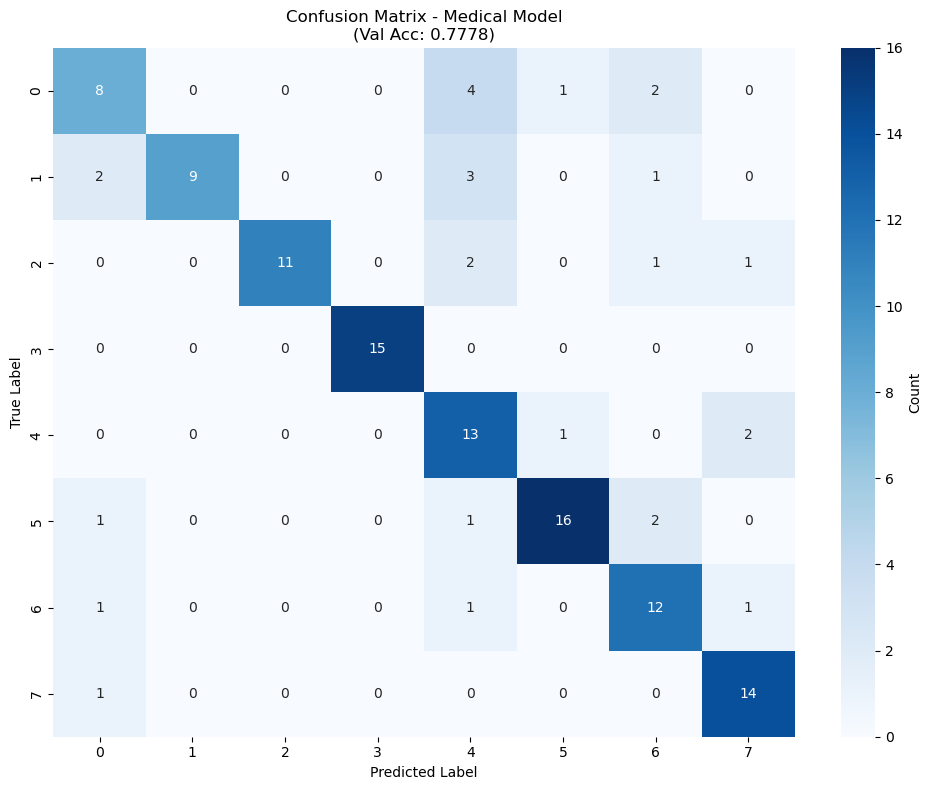

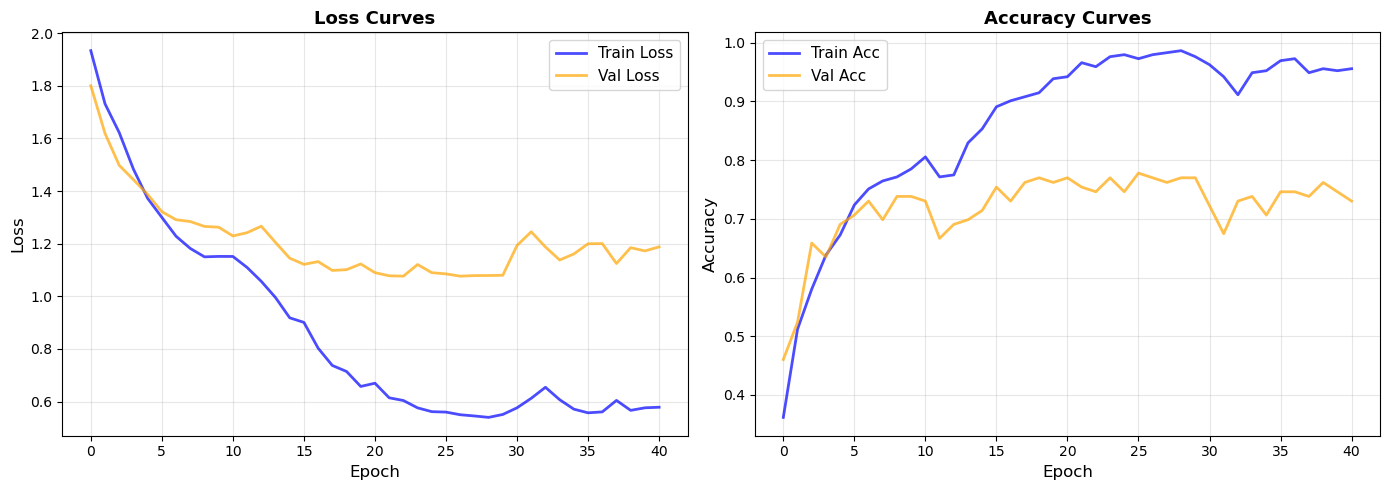

In [ ]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
CSV_PATH = "mmdental_multiclass_balanced.csv"
EMB_SAVE_DIR = "embeddings_for_multimodal"
BATCH_SIZE = 32
EPOCHS = 100
LR = 5e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


os.makedirs(EMB_SAVE_DIR, exist_ok=True)

MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"


print(f"Device: {DEVICE}")
print(f"Model: {MODEL_NAME}")

# ---------------- LOAD DATA ----------------
print("\nLoading data...")
df = pd.read_csv(CSV_PATH)
df = df.drop(columns=["target_disease"])

labels = df["label"].values
num_classes = len(np.unique(labels))
print(f"Number of classes: {num_classes}")
print(f"Total samples: {len(labels)}")

class_counts = np.bincount(labels)
print(f"\nClass distribution:")
for i, count in enumerate(class_counts):
    percentage = (count / len(labels)) * 100
    print(f"  Class {i}: {count} samples ({percentage:.2f}%)")

class_weights = len(labels) / (num_classes * class_counts)
class_weights = torch.FloatTensor(class_weights).to(DEVICE)
print(f"\nClass weights for loss function:")
for i, weight in enumerate(class_weights):
    print(f"  Class {i}: {weight:.4f}")

text_cols = [c for c in df.columns if c != "label"]
df["text"] = df[text_cols].astype(str).agg(" ".join, axis=1)
texts = df["text"].tolist()

# Print sample text
print(f"\nSample text (first 200 chars):\n{texts[0][:200]}...")

X_train, X_val, y_train, y_val = train_test_split(
    texts, labels, test_size=0.3, stratify=labels, random_state=42
)

print(f"\nTrain samples: {len(X_train)}")
print(f"Val samples: {len(X_val)}")

# ---------------- PRE-COMPUTE EMBEDDINGS ----------------
print(f"\nLoading medical domain encoder: {MODEL_NAME}")
text_encoder = SentenceTransformer(MODEL_NAME, device=DEVICE)
EMB_DIM = text_encoder.get_sentence_embedding_dimension()
print(f"Embedding dimension: {EMB_DIM}")

print("\nEncoding training data...")
X_train_emb = text_encoder.encode(
    X_train,
    convert_to_tensor=True,
    device=DEVICE,
    show_progress_bar=True,
    batch_size=16
)

print("Encoding validation data...")
X_val_emb = text_encoder.encode(
    X_val,
    convert_to_tensor=True,
    device=DEVICE,
    show_progress_bar=True,
    batch_size=16
)

# Convert labels to tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

print(f"Training embeddings shape: {X_train_emb.shape}")
print(f"Validation embeddings shape: {X_val_emb.shape}")

# ---------------- SAVE EMBEDDINGS FOR MULTIMODAL USE ----------------
print(f"\nSaving embeddings to '{EMB_SAVE_DIR}/' for multimodal fusion...")

# Save training embeddings and labels
torch.save(X_train_emb.cpu(), f"{EMB_SAVE_DIR}/train_text_embeddings.pt")
torch.save(y_train_tensor, f"{EMB_SAVE_DIR}/train_labels.pt")
np.save(f"{EMB_SAVE_DIR}/train_texts.npy", np.array(X_train))

# Save validation embeddings and labels
torch.save(X_val_emb.cpu(), f"{EMB_SAVE_DIR}/val_text_embeddings.pt")
torch.save(y_val_tensor, f"{EMB_SAVE_DIR}/val_labels.pt")
np.save(f"{EMB_SAVE_DIR}/val_texts.npy", np.array(X_val))

# Save metadata for multimodal integration
metadata = {
    'embedding_dim': EMB_DIM,
    'num_classes': num_classes,
    'model_name': MODEL_NAME,
    'num_train_samples': len(X_train),
    'num_val_samples': len(X_val),
    'text_columns': text_cols,
}
torch.save(metadata, f"{EMB_SAVE_DIR}/metadata.pt")

# ---------------- DATASET FOR PRE-COMPUTED EMBEDDINGS ----------------
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = embeddings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

train_ds = EmbeddingDataset(X_train_emb, y_train_tensor)
val_ds = EmbeddingDataset(X_val_emb, y_val_tensor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

# ---------------- IMPROVED CLASSIFIER WITH REGULARIZATION ----------------
class RobustClassifier(nn.Module):
    def __init__(self, emb_dim, num_classes, dropout=0.25):
        super().__init__()

        self.net = nn.Sequential(
            # First block
            nn.LayerNorm(emb_dim),
            nn.Linear(emb_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),

            # Second block
            nn.LayerNorm(512),
            nn.Linear(512, 256),
            nn.GELU(),
            # nn.Dropout(dropout),

            # Third block
            nn.LayerNorm(256),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout * 0.7),

            nn.LayerNorm(128),
            nn.Linear(128, 64),
            nn.GELU(),

            nn.LayerNorm(64),
            nn.Linear(64, 32),
            nn.GELU(),

            # Output layer
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = RobustClassifier(EMB_DIM, num_classes, dropout=0.25).to(DEVICE)


criterion = nn.CrossEntropyLoss(
    weight=class_weights,  # class weights
    label_smoothing=0.1
)
print(f"\n✓ Using weighted CrossEntropyLoss to handle class imbalance")

# AdamW with weight decay for regularization
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=0.05
)

# Cosine annealing scheduler for better convergence
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

# Early stopping parameters
best_val_acc = 0
patience = 15
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    # TRAINING
    model.train()
    total_loss, correct, total = 0, 0, 0

    for emb, y in train_loader:
        emb, y = emb.to(DEVICE), y.to(DEVICE)

        logits = model(emb)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    scheduler.step()

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # VALIDATION
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for emb, y in val_loader:
            emb, y = emb.to(DEVICE), y.to(DEVICE)

            logits = model(emb)
            loss = criterion(logits, y)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    val_loss = total_loss / len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Print progress
    if (epoch + 1) % 5 == 0 or epoch < 5:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Early stopping and model saving
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_medical_model.pt')
        print(f"  ✓ New best validation accuracy: {val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⚠ Early stopping triggered at epoch {epoch+1}")
            print(f"Best validation accuracy: {best_val_acc:.4f}")
            break

# Load best model for final evaluation
print(f"\nLoading best model (Val Acc: {best_val_acc:.4f})...")
model.load_state_dict(torch.load('best_medical_model.pt'))

# ---------------- FINAL EVALUATION ----------------
print("\n" + "="*60)
print("FINAL EVALUATION ON VALIDATION SET")
print("="*60 + "\n")

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for emb, y in val_loader:
        emb, y = emb.to(DEVICE), y.to(DEVICE)
        logits = model(emb)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

final_acc = (np.array(all_preds) == np.array(all_labels)).mean()

print(f"BEST VALIDATION ACCURACY: {best_val_acc:.4f}")
print(f"Final overfitting gap: {train_accs[-1] - val_accs[-1]:.4f}")
print(f"\n{'='*60}\n")

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, zero_division=0))

# Per-class accuracy analysis
print("\nPer-Class Performance:")
for i in range(num_classes):
    class_mask = np.array(all_labels) == i
    if class_mask.sum() > 0:
        class_acc = (np.array(all_preds)[class_mask] == i).mean()
        print(f"  Class {i}: {class_acc:.4f} ({class_mask.sum()} samples)")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar_kws={'label': 'Count'})
plt.title(f"Confusion Matrix - Medical Model\n(Val Acc: {best_val_acc:.4f})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig('confusion_matrix_medical.png', dpi=300, bbox_inches='tight')
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label="Train Loss", alpha=0.7, linewidth=2, color='blue')
ax1.plot(val_losses, label="Val Loss", alpha=0.7, linewidth=2, color='orange')
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.legend(fontsize=11)
ax1.set_title("Loss Curves", fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)

ax2.plot(train_accs, label="Train Acc", alpha=0.7, linewidth=2, color='blue')
ax2.plot(val_accs, label="Val Acc", alpha=0.7, linewidth=2, color='orange')

ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.legend(fontsize=11)
ax2.set_title("Accuracy Curves", fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_medical.png', dpi=300, bbox_inches='tight')
plt.show()